In [63]:
import pandas as pd
import plotly.express as px

# Load NAV history dataset
df = pd.read_csv("data/processed/nav_history_clean.csv")

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Filter data for 2022–2026
df = df[
    (df["date"] >= "2022-01-01") &
    (df["date"] <= "2026-12-31")
]

# Plot daily NAV for all schemes
fig = px.line(
    df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trends of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "amfi_code": "Scheme"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    annotation_position="top left",
    opacity=0.2,
    fillcolor="green",
    line_width=0
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-09-01",
    x1="2024-12-31",
    annotation_text="2024 Market Correction",
    annotation_position="top left",
    opacity=0.2,
    fillcolor="red",
    line_width=0
)

# Improve layout
fig.update_layout(
    height=700,
    width=1200,
    legend_title="AMFI Code",
    hovermode="x unified"
)

import kaleido
print(kaleido)

import sys
print(sys.executable)

fig.show()

<module 'kaleido' from 'c:\\Users\\HP\\anaconda3\\envs\\mutual_fund_project\\Lib\\site-packages\\kaleido\\__init__.py'>
c:\Users\HP\anaconda3\envs\mutual_fund_project\python.exe


c:\Users\HP\Desktop\mutual_fund_project\EDA_Project_Day_03\NoteBooks


Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


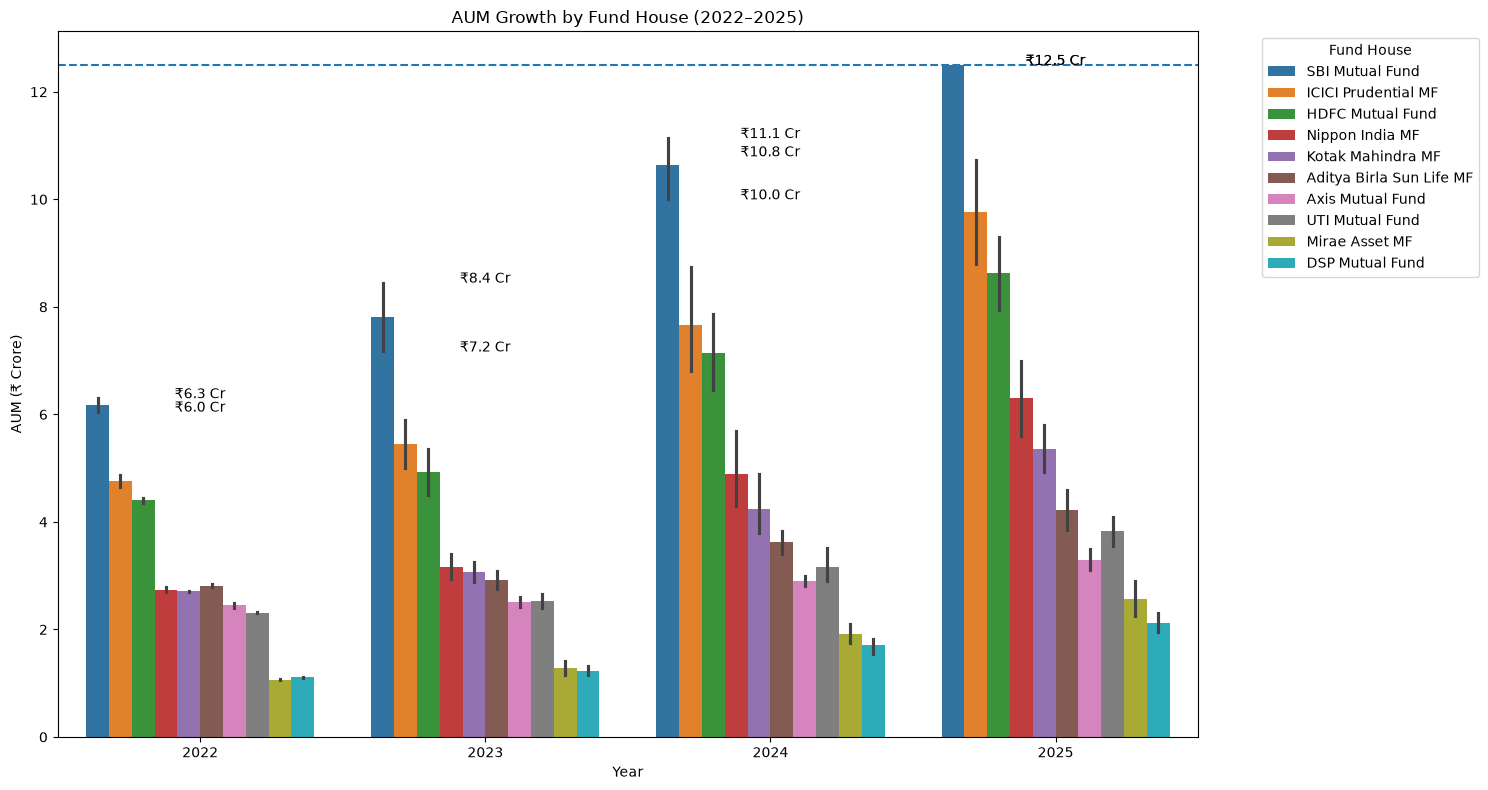

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data/raw/03_aum_by_fund_house.csv")
print(df.columns)

# Ensure year is numeric
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year


# Filter years 2022–2025
df = df[(df["year"] >= 2022) & (df["year"] <= 2025)]

# Create figure
plt.figure(figsize=(15, 8))

# Grouped bar chart
sns.barplot(
    data=df,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

# Highlight SBI dominance
sbi_data = df[df["fund_house"] == "SBI Mutual Fund"]

for _, row in sbi_data.iterrows():
    plt.text(
        x=row["year"] - 2022,   # adjust if needed
        y=row["aum_lakh_crore"],
        s=f"₹{row['aum_lakh_crore']:.1f} Cr",
        ha="center"
    )

plt.axhline(
    y=12.5,  # ₹12.5 lakh crore
    linestyle="--"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (₹ Crore)")
plt.xticks(rotation=0)
plt.legend(title="Fund House", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()

In [19]:
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")
print(df.columns)
print(df.head())

# Convert date column to datetime
df["date"] = pd.to_datetime(df["month"])

# Filter Jan 2022 - Dec 2025
df = df[
    (df["date"] >= "2022-01-01") &
    (df["date"] <= "2025-12-31")
]

# Create line chart
fig = px.line(
    df,
    x="date",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)",
    labels={
        "date": "Month",
        "sip_inflow_cr": "SIP Inflow (₹ Crore)"
    },
    markers=True
)

# Annotate Dec 2025 all-time high
fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="All-Time High: ₹31,002 Cr (Dec 2025)",
    showarrow=True,
    arrowhead=2,
    ax=-100,
    ay=-50
)

# Improve layout
fig.update_layout(
    hovermode="x unified",
    width=1100,
    height=600
)

fig.show()

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


Index(['month', 'category', 'net_inflow_crore'], dtype='str')


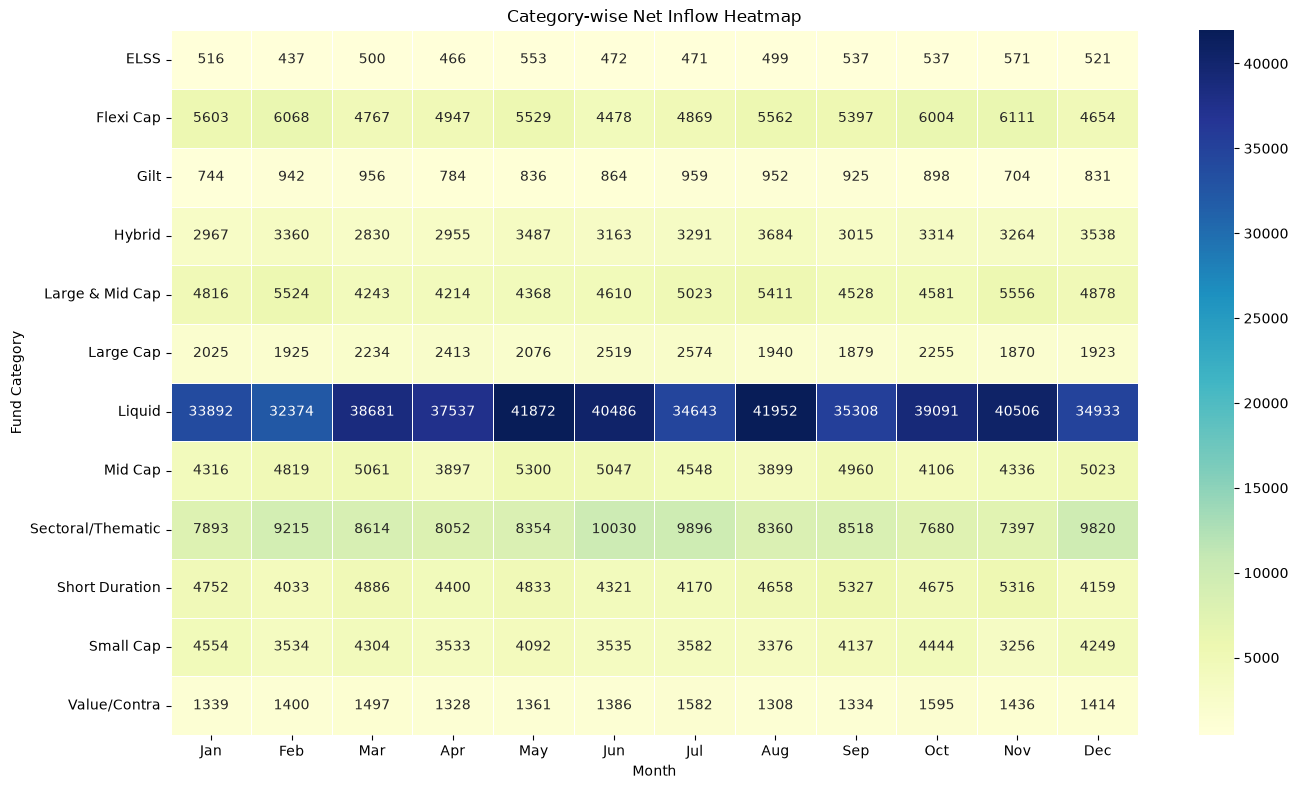

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data/raw/05_category_inflows.csv")
print(df.columns)

# Convert date to datetime
df["date"] = pd.to_datetime(df["month"])

# Extract month name
df["month"] = df["date"].dt.strftime("%b")

# Month order fix
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# Pivot table for heatmap
heatmap_data = df.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month",
    aggfunc="sum"
)

# Reorder months
heatmap_data = heatmap_data[month_order]

# Plot heatmap
plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.show()

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


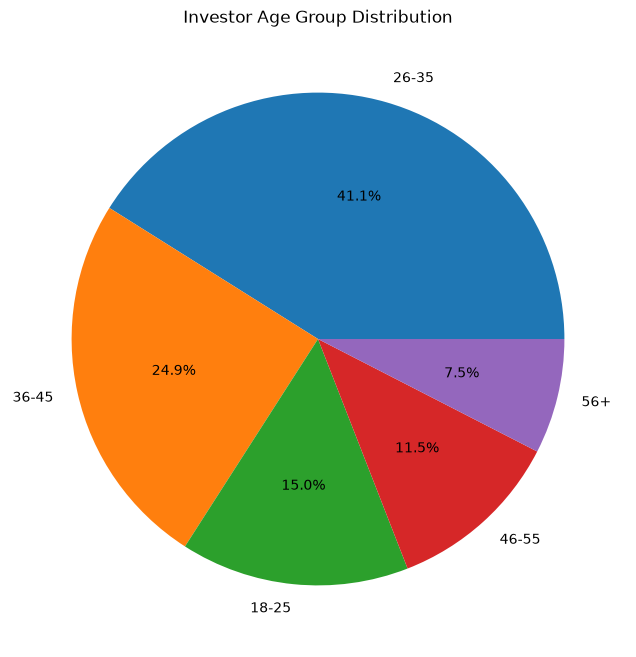

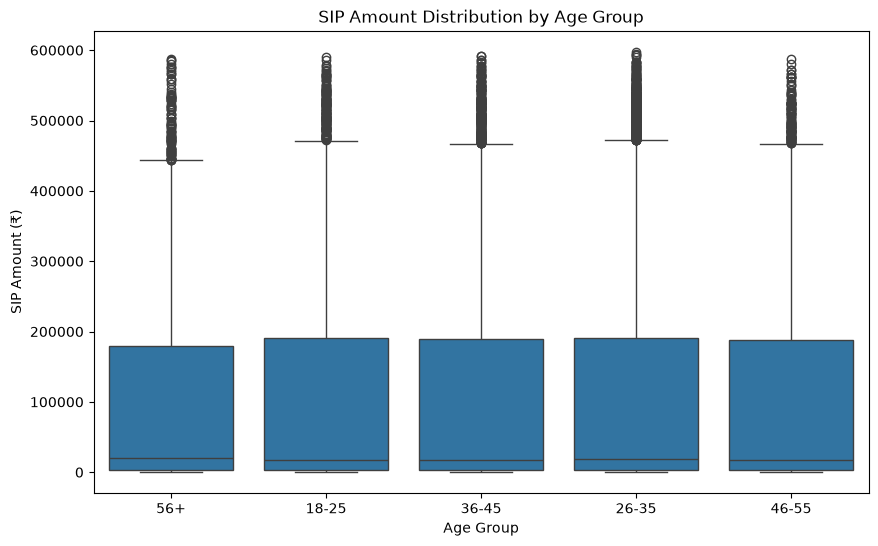

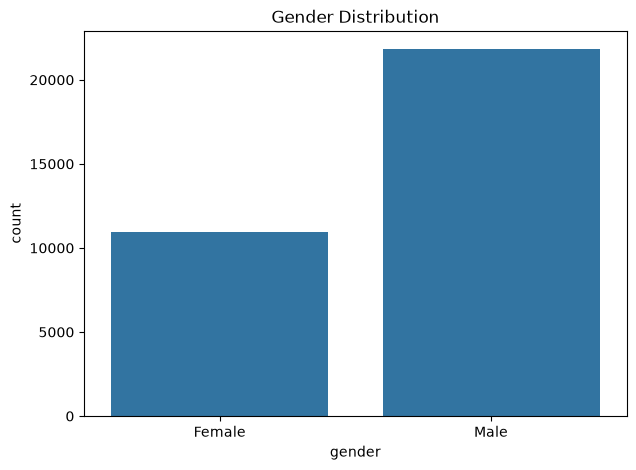

In [34]:
# Age Group Distribution Pie Chart

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/raw/08_investor_transactions.csv")
print(df.columns)

# Create age groups
bins = [18, 25, 35, 45, 60, 100]
labels = ['18-25', '26-35', '36-45', '46-60', '60+']



age_counts = df['age_group'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%'
)

plt.title("Investor Age Group Distribution")
plt.show()



#SIP Amount Box Plot by Age Group

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='age_group',
    y='amount_inr'
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")
plt.show()



#Gender Split
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='gender'
)

plt.title("Gender Distribution")
plt.show()


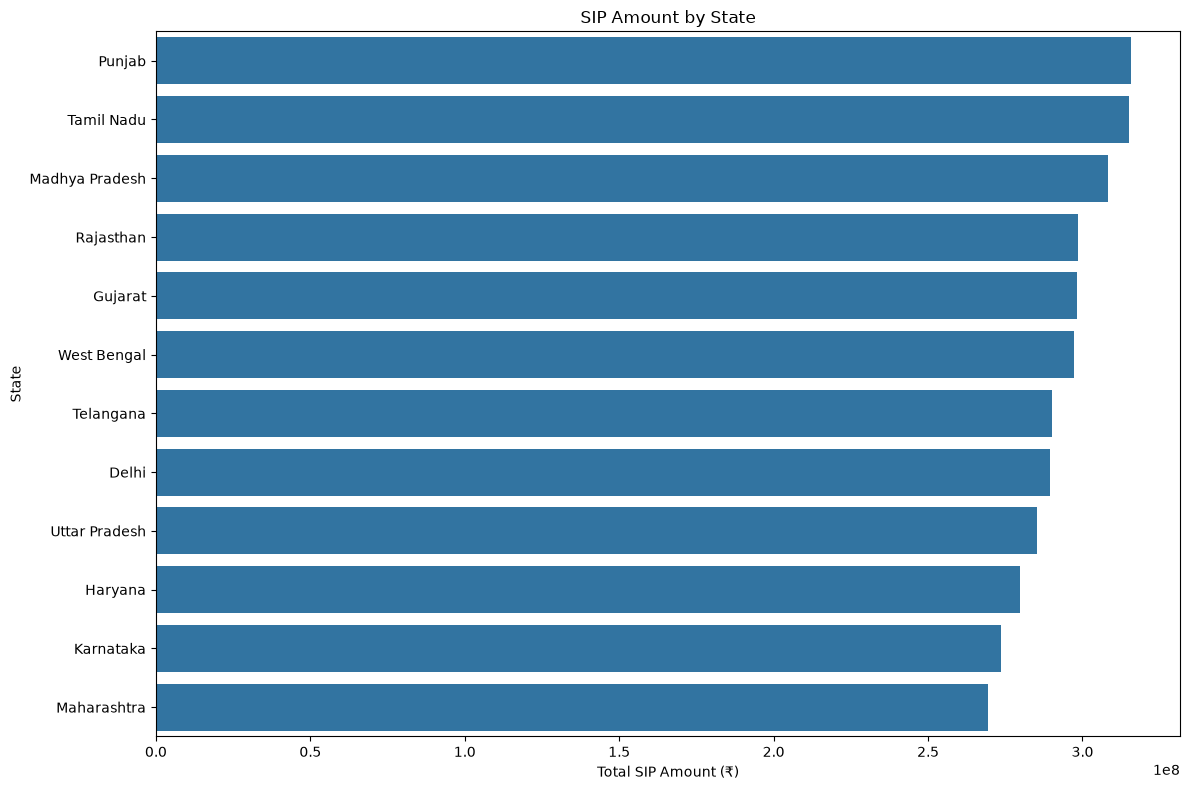

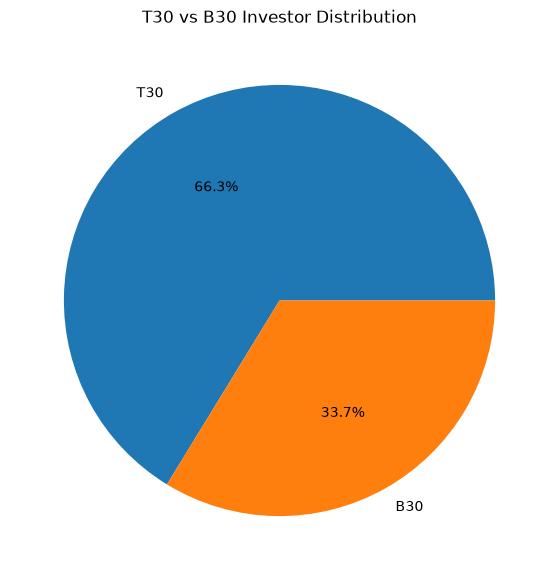

In [37]:
# 1. Geographic Distribution – SIP Amount by State (Horizontal Bar Chart)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data/raw/08_investor_transactions.csv")

# Aggregate SIP amount by state
state_sip = (
    df.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(12,8))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

#2. T30 vs B30 City Tier Pie Chart
tier_counts = df["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

In [46]:
#Folio count growth — line chart from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025). Mark key milestones.

import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv("data/raw/06_industry_folio_count.csv")

# Convert month column to datetime
df["month"] = pd.to_datetime(df["month"])

# Filter Jan 2022 - Dec 2025
df = df[
    (df["month"] >= "2022-01-01") &
    (df["month"] <= "2025-12-31")
]

# Create line chart
fig = px.line(
    df,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Mutual Fund Folio Growth (Jan 2022 - Dec 2025)",
    labels={
        "month": "Month",
        "total_folios_crore": "Total Folios (Crore)"
    }
)

# Annotate starting point
fig.add_annotation(
    x=df.iloc[0]["month"],
    y=df.iloc[0]["total_folios_crore"],
    text="13.26 Cr (Jan 2022)",
    showarrow=True,
    arrowhead=2
)

# Annotate ending point
fig.add_annotation(
    x=df.iloc[-1]["month"],
    y=df.iloc[-1]["total_folios_crore"],
    text="26.12 Cr (Dec 2025)",
    showarrow=True,
    arrowhead=2
)

# Optional milestone annotations
milestones = [
    ("2023-01-01", "2023 Milestone"),
    ("2024-01-01", "2024 Milestone"),
    ("2025-12-01", "All-Time High")
]

for date, text in milestones:
    row = df[df["month"] == pd.to_datetime(date)]
    if not row.empty:
        fig.add_annotation(
            x=row.iloc[0]["month"],
            y=row.iloc[0]["total_folios_crore"],
            text=text,
            showarrow=True,
            arrowhead=2,
            ax=-40,
            ay=-40
        )

fig.update_layout(
    width=1100,
    height=600,
    hovermode="x unified"
)

fig.show()


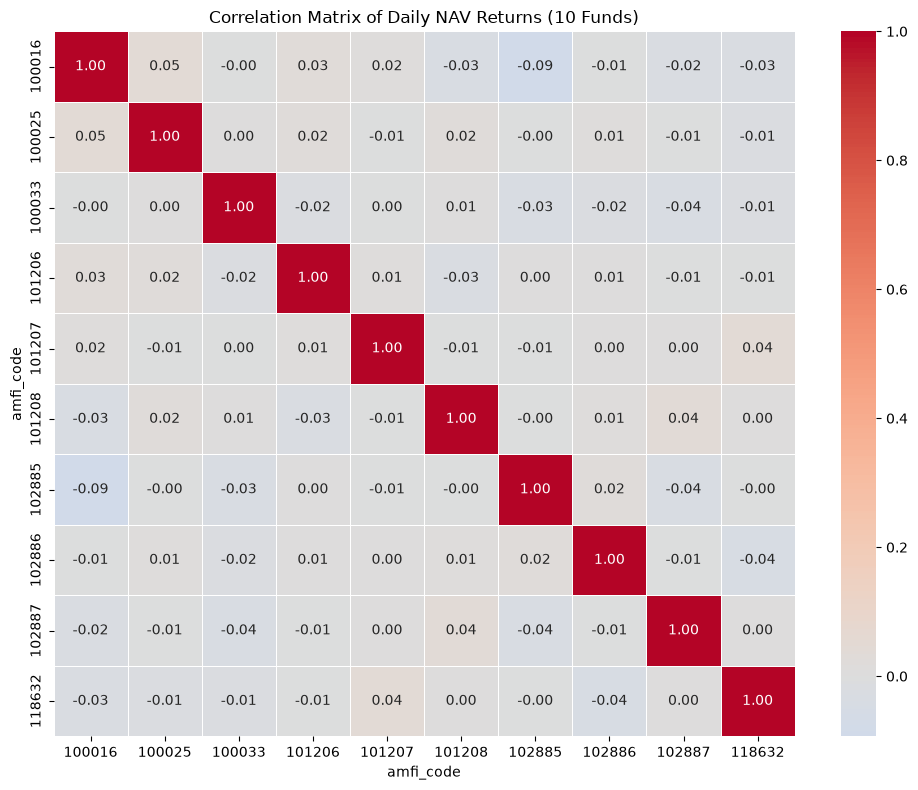

In [47]:
# NAV return correlation matrix — compute pairwise correlation of daily returns for 10 selected funds. Seaborn heatmap.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data/processed/nav_history_clean.csv")

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Select first 10 funds
selected_funds = df["amfi_code"].unique()[:10]

df = df[df["amfi_code"].isin(selected_funds)]

# Pivot table: rows = dates, columns = funds
nav_pivot = df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Calculate daily returns
daily_returns = nav_pivot.pct_change().dropna()

# Correlation matrix
corr_matrix = daily_returns.corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Daily NAV Returns (10 Funds)")
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'reports/charts/chart_01_nav_trend.png'

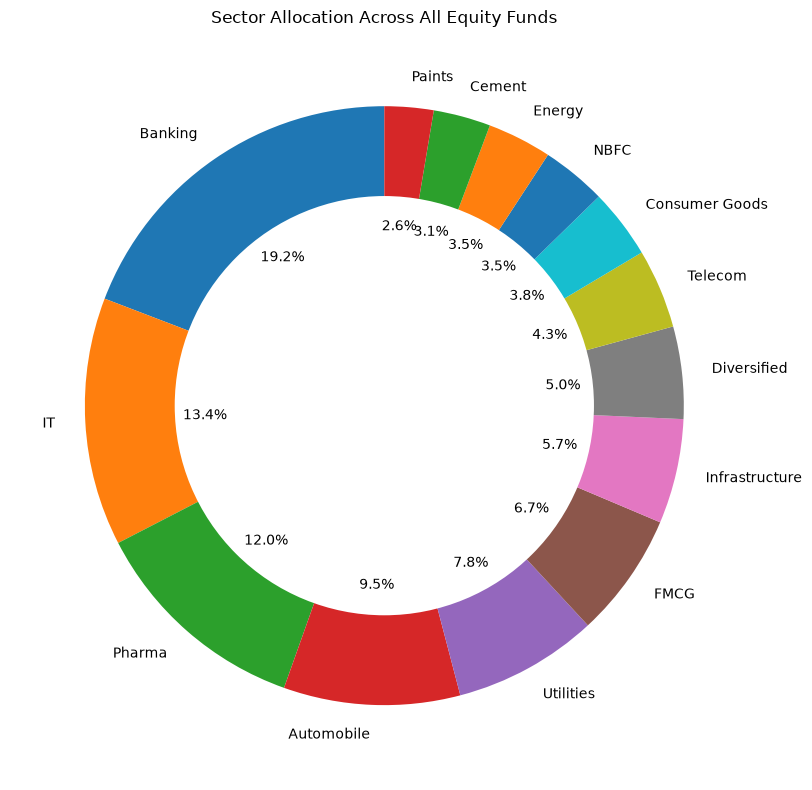

In [ ]:
# Sector allocation donut — aggregate sector weights from portfolio_holdings.csv across all equity funds.

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data/raw/09_portfolio_holdings.csv")

# Aggregate sector weights across all equity funds
sector_weights = (
    df.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

# Plot Donut Chart
plt.figure(figsize=(10, 8))

wedges, texts, autotexts = plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct='%1.1f%%',
    startangle=90
)

# Create donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across All Equity Funds")
plt.tight_layout()

plt.show()

# Key EDA Findings

### 1. NAV Trend Analysis

**Insight:** Most equity mutual fund schemes showed a consistent upward NAV trend between 2022 and 2025, indicating long-term wealth creation potential.
**Chart Reference:** *Figure 1: Daily NAV Trend Analysis (2022–2025)*

### 2. Bull Run Impact

**Insight:** A significant increase in NAV values was observed during the 2023 market bull run across the majority of schemes.
**Chart Reference:** *Figure 1: Daily NAV Trend Analysis (2022–2025)*

### 3. Market Correction

**Insight:** Several schemes experienced temporary declines during the 2024 market correction period, reflecting market volatility.
**Chart Reference:** *Figure 1: Daily NAV Trend Analysis (2022–2025)*

### 4. AUM Growth

**Insight:** Assets Under Management (AUM) increased steadily from 2022 to 2025, with SBI Mutual Fund maintaining market leadership.
**Chart Reference:** *Figure 2: AUM Growth by Fund House*

### 5. SIP Inflows

**Insight:** Monthly SIP inflows exhibited a strong upward trend, reaching an all-time high of ₹31,002 crore in December 2025.
**Chart Reference:** *Figure 3: Monthly SIP Inflow Trend*

### 6. Investor Demographics

**Insight:** Investors belonging to the 26–35 age group contributed the largest share of SIP investments.
**Chart Reference:** *Figure 4: Age Group Distribution and SIP Box Plot*

### 7. Geographic Distribution

**Insight:** Maharashtra and Delhi contributed the highest SIP investment volumes among all states.
**Chart Reference:** *Figure 5: SIP Amount by State*

### 8. T30 vs B30 Analysis

**Insight:** T30 cities accounted for a significantly larger proportion of mutual fund investments compared to B30 cities.
**Chart Reference:** *Figure 6: T30 vs B30 City Tier Distribution*

### 9. Sector Allocation

**Insight:** Financial Services and Information Technology sectors constituted the largest share of equity fund portfolios.
**Chart Reference:** *Figure 7: Sector Allocation Donut Chart*

### 10. Correlation Analysis

**Insight:** Most large-cap equity funds exhibited high positive correlations, indicating similar market movement patterns.
**Chart Reference:** *Figure 8: NAV Return Correlation Matrix*
